In [22]:
# Imports & helpers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import differential_evolution
from scipy.spatial.distance import cdist
import sys

# Find the shared helpers from the notebook folder or either repository root.
stage = next(
    stage
    for root in (Path.cwd(), *Path.cwd().parents)
    for stage in (root / "stage-2-bbo", root / "Capstone/imperial-capstone/stage-2-bbo")
    if (stage / "src/initial_exploration.py").is_file()
)
if str(stage / "src") not in sys.path:
    sys.path.insert(0, str(stage / "src"))

from initial_exploration import (
    plot_ranked_locations, plot_sampling_gaps,
)


In [23]:
# Data location, paths, etc.
data_path = str(stage / "Week2_Notebooks" / "function_1")
data_filename = "observations.csv"
full_data_path = data_path + "\\" + data_filename
figures = Path(data_path) / "figures"
figures.mkdir(parents=True, exist_ok=True)

In [24]:
# Basic data load
print(f"Loading data from: {full_data_path}")
data = pd.read_csv(full_data_path)

Loading data from: c:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\stage-2-bbo\Week2_Notebooks\function_1\observations.csv


In [25]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'y'], dtype='str')


In [26]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
y                 0
dtype: int64


In [27]:
# Prepare observation labels for the exploration plots
plot_data = data.copy()
plot_data["rank"] = (
    plot_data["y"]
    .rank(ascending=False, method="min")
    .astype(int)
)

In [6]:
# Splitting our data into inputs X and outputs y
output_column = "y"
input_columns = ["x1", "x2"]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [28]:
# So now we have:

# data	       = Observations as loaded from the CSV
# X, y	       = Inputs and outputs selected from those observations
# plot_data	   = A separate copy enriched for the exploration plots

In [7]:
# Ok, here is where we go into more problem-specific territory. 
# We are approaching this as primarily a Bayesian optimization problem where we need to balance exploration and exploitation. 
# We will use a Gaussian Process to model the underlying function and then use an acquisition function to decide where to sample next.
# But first, let's visualize the data to get a better understanding of the underlying function.



Exact zeros: 0 (included on the left; omitted from the log view).
The dotted lines mark zero on the left and the near-zero boundary on the right.


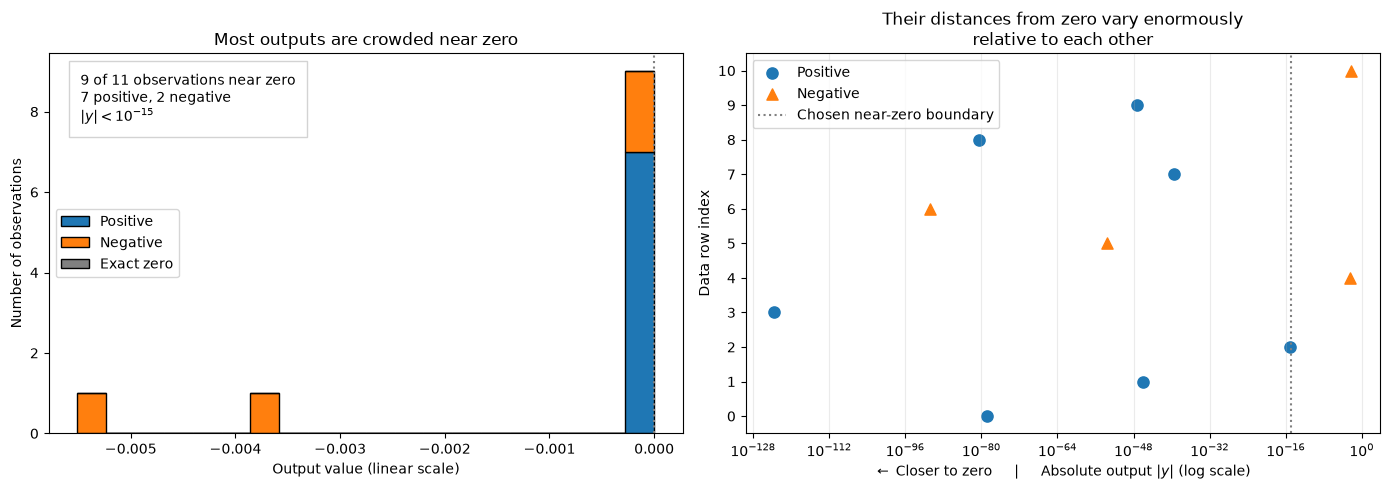

In [8]:
# Two views: how close the outputs are to zero, and how their magnitudes differ.
# This boundary describes the plot; it is not a rule for rounding outputs to zero.
near_zero_exponent = -15
near_zero_limit = 10.0 ** near_zero_exponent
near_zero_count = (y.abs() < near_zero_limit).sum()
near_zero_positive_count = ((y > 0) & (y < near_zero_limit)).sum()
near_zero_negative_count = ((y < 0) & (y > -near_zero_limit)).sum()
zero_count = (y == 0).sum()

fig, (linear_ax, log_ax) = plt.subplots(1, 2, figsize=(14, 5))

# Use shared bins and stack the counts by sign: a bin crossing zero can contain both.
# Include exact zeros as a separate group so every observation remains in this view.
linear_ax.hist(
    [y[y > 0], y[y < 0], y[y == 0]],
    bins=20, stacked=True, edgecolor="black",
    color=["tab:blue", "tab:orange", "grey"],
    label=["Positive", "Negative", "Exact zero"],
)
linear_ax.legend(loc="center left")
linear_ax.axvline(0, color="grey", linestyle=":")
linear_ax.set_title("Most outputs are crowded near zero")
linear_ax.set_xlabel("Output value (linear scale)")
linear_ax.set_ylabel("Number of observations")
linear_ax.text(
    0.05, 0.95,
    f"{near_zero_count} of {len(y)} observations near zero\n"
    + f"{near_zero_positive_count} positive, {near_zero_negative_count} negative"
    + (f", {zero_count} exact zero" if zero_count else "")
    + "\n" + rf"$|y| < 10^{{{near_zero_exponent}}}$",
    transform=linear_ax.transAxes, va="top",
    bbox=dict(facecolor="white", edgecolor="lightgrey", pad=8),
)

# A logarithmic axis cannot include zero. Absolute values give distance from zero;
# colour and marker shape retain the original sign. Each row is one observation.
for label, outputs, colour, marker in [
    ("Positive", y[y > 0], "tab:blue", "o"),
    ("Negative", y[y < 0], "tab:orange", "^"),
]:
    log_ax.scatter(
        outputs.abs(), outputs.index,
        color=colour, marker=marker, s=65, label=label,
    )

# Plot the magnitudes themselves; the axis supplies the logarithmic spacing
# and labels them as powers of ten rather than showing their logarithms.
log_ax.set_xscale("log")
log_ax.axvline(
    near_zero_limit, color="grey", linestyle=":",
    label="Chosen near-zero boundary",
)
log_ax.set_title("Their distances from zero vary enormously\nrelative to each other")
log_ax.set_xlabel(r"$\leftarrow$ Closer to zero     |     Absolute output $|y|$ (log scale)")
log_ax.set_ylabel("Data row index")
log_ax.set_yticks(y.index)
log_ax.grid(axis="x", alpha=0.25)
log_ax.legend()

print(f"Exact zeros: {zero_count} (included on the left; omitted from the log view).")
print("The dotted lines mark zero on the left and the near-zero boundary on the right.")
plt.tight_layout()
plt.show()


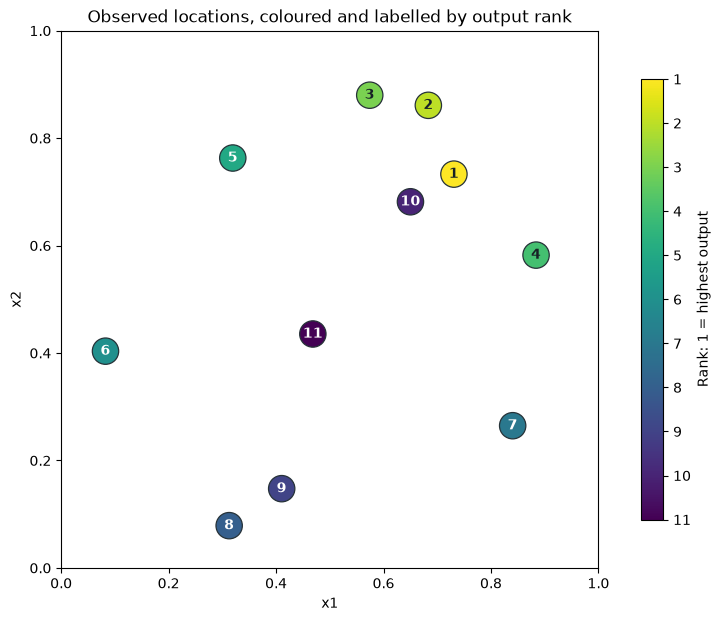

In [9]:
# Moving on to analysis of input space coverage and output ranking. 
# This first plot shows the locations of the observations, ranked by their outputs. 
plot_ranked_locations(data, save_to=figures / "ranked-locations.png")

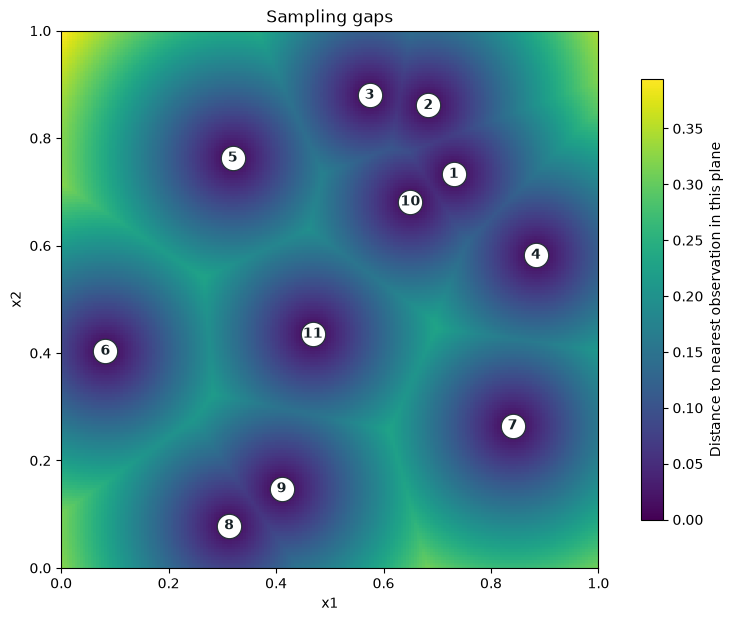

In [10]:
# This second plot shows the gaps in the input space that have not been sampled yet. 
# These plots will help us understand how well the input space has been explored and where we might want to sample next.
plot_sampling_gaps(data, save_to=figures / "sampling-gaps.png")

In [11]:
# There are still some gaps in the input space that have not been sampled yet.
# For this particular function, I am going to prioritise exploration over exploitation for longer
# because 2D space is relatively cheap to explore.

In [12]:
# Helpers for maximin candidate selection and comparison, and for coverage value comparison.
MAX_VALUE = 0.999999

def make_2d_grid(n):
    axis = np.linspace(0.0, MAX_VALUE, n)
    x, y = np.meshgrid(axis, axis)

    return np.column_stack([
        x.ravel(),
        y.ravel()
    ])


def optimise_joint_minimax(existing, q, coverage_space, seed=42):
    n_dimensions = existing.shape[1]

    distance_to_existing = cdist(
        coverage_space,
        existing
    ).min(axis=1)

    def objective(flat_proposed):
        proposed = flat_proposed.reshape(q, n_dimensions)

        distance_to_proposed = cdist(
            coverage_space,
            proposed
        ).min(axis=1)

        nearest_distance = np.minimum(
            distance_to_existing,
            distance_to_proposed
        )

        return nearest_distance.max()

    result = differential_evolution(
        objective,
        bounds=[(0.0, MAX_VALUE)] * (q * n_dimensions),
        init="sobol",
        seed=seed,
        polish=True
    )

    return result.x.reshape(q, n_dimensions)

In [ ]:
# Identifying the next best candidates.  
# Rather than assuming 'just one more' for the selection of further exploratory submissions, 
# I will commit to spend N additional candidates on exploration. 
# First, decide how many is most useful. Then, select the best candidates for that number.

optimization_space = make_2d_grid(51)
coverage_evaluation_space = make_2d_grid(201)
results = []

for q in range(13):
    if q == 0:
        proposed = np.empty((0, 2))
    else:
        proposed = optimise_joint_minimax(
            existing=X,
            q=q,
            coverage_space=optimization_space
        )

    design = np.vstack([X, proposed])

    distances = cdist(
        coverage_evaluation_space,
        design
    ).min(axis=1)

    results.append({
        "q": q,
        "max_distance": distances.max(),
        "p95_distance": np.percentile(distances, 95)
    })

    # Function 1 - Desktop - 4m47s

In [14]:
coverage_results = pd.DataFrame(results)
coverage_results

,q,max_distance,p95_distance
0,0,0.397752,0.270045
1,1,0.345728,0.243403
2,2,0.322449,0.233374
3,3,0.309143,0.220547
4,4,0.244186,0.199155
5,5,0.228464,0.190965
6,6,0.220758,0.180228
7,7,0.215695,0.177901
8,8,0.205618,0.165392
9,9,0.205280,0.164256


In [15]:
coverage_results["relative_max_distance"] = (
    coverage_results["max_distance"]
    / coverage_results.loc[0, "max_distance"]
)

coverage_results["coverage_improvement"] = (
    1.0 - coverage_results["relative_max_distance"]
)

coverage_results["marginal_improvement"] = (
    coverage_results["max_distance"]
    .shift(1)
    - coverage_results["max_distance"]
)

coverage_results

,q,max_distance,p95_distance,relative_max_distance,coverage_improvement,marginal_improvement
0,0,0.397752,0.270045,1.000000,0.000000,NaN
1,1,0.345728,0.243403,0.869206,0.130794,0.052024
2,2,0.322449,0.233374,0.810677,0.189323,0.023280
3,3,0.309143,0.220547,0.777226,0.222774,0.013305
4,4,0.244186,0.199155,0.613915,0.386085,0.064957
5,5,0.228464,0.190965,0.574388,0.425612,0.015722
6,6,0.220758,0.180228,0.555015,0.444985,0.007706
7,7,0.215695,0.177901,0.542286,0.457714,0.005063
8,8,0.205618,0.165392,0.516950,0.483050,0.010077
9,9,0.205280,0.164256,0.516101,0.483899,0.000338


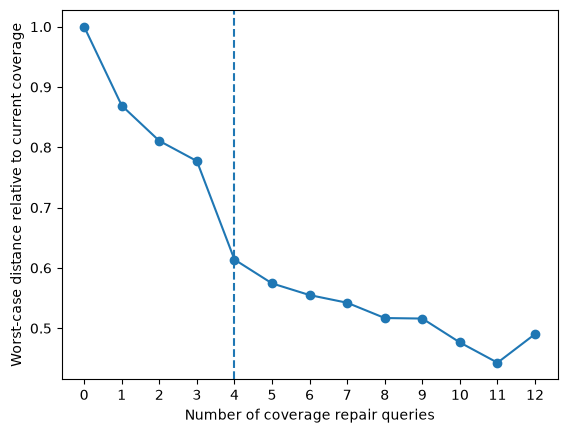

In [16]:

plt.plot(
    coverage_results["q"],
    coverage_results["relative_max_distance"],
    marker="o"
)

plt.axvline(4, linestyle="--")

plt.xlabel("Number of coverage repair queries")
plt.ylabel("Worst-case distance relative to current coverage")
plt.xticks(range(13))
plt.show()

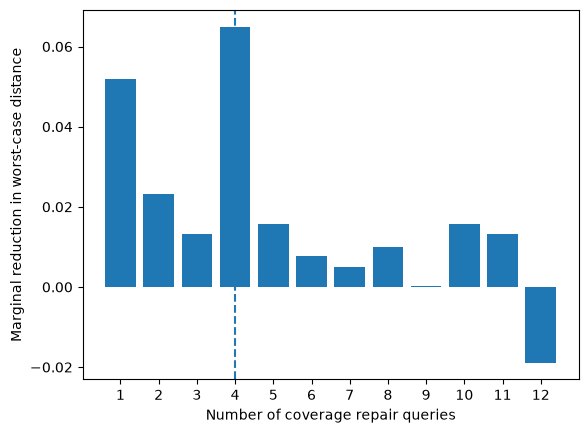

In [17]:
plt.bar(
    coverage_results["q"][1:],
    coverage_results["marginal_improvement"][1:]
)

plt.axvline(4, linestyle="--")

plt.xlabel("Number of coverage repair queries")
plt.ylabel("Marginal reduction in worst-case distance")
plt.xticks(range(1, 13))
plt.show()

In [18]:
coverage_results["max_distance"].diff()

0          NaN
1    -0.052024
2    -0.023280
3    -0.013305
4    -0.064957
5    -0.015722
6    -0.007706
7    -0.005063
8    -0.010077
9    -0.000338
10   -0.015782
11   -0.013332
12    0.018897
Name: max_distance, dtype: float64

In [19]:
best_q4 = None

for seed in range(5):
    proposed = optimise_joint_minimax(
        existing=X,
        q=4,
        coverage_space=optimization_space,
        seed=seed
    )

    design = np.vstack([X, proposed])

    distances = cdist(
        coverage_evaluation_space,
        design
    ).min(axis=1)

    score = distances.max()

    if best_q4 is None or score < best_q4["score"]:
        best_q4 = {
            "score": score,
            "proposed": proposed,
            "seed": seed
        }

In [20]:
coverage_queries = pd.DataFrame(
    best_q4["proposed"],
    columns=["x1", "x2"]
)

coverage_queries

,x1,x2
0,0.836244,0.948003
1,0.110603,0.211978
2,0.790513,0.056642
3,0.114764,0.818024


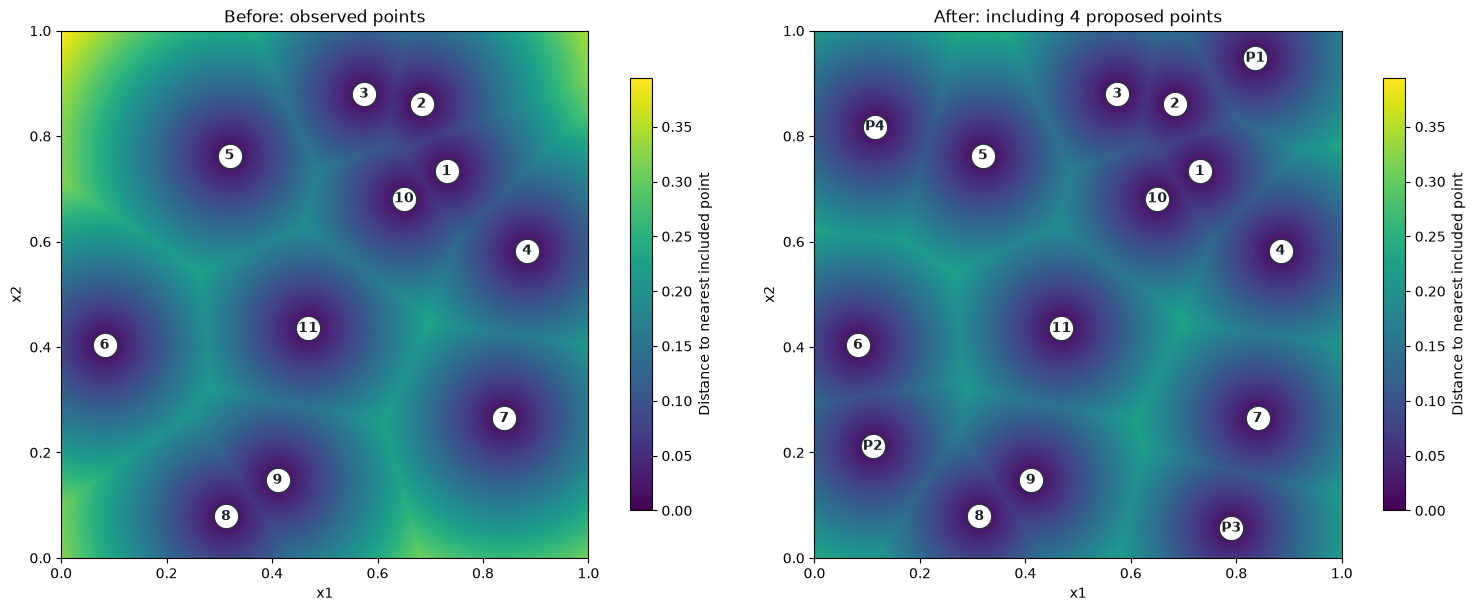

In [21]:
# Compare current coverage with coverage after sampling the proposed points.
proposed_for_plot = coverage_queries.assign(
    rank=[f"P{i + 1}" for i in range(len(coverage_queries))]
)
combined_for_plot = pd.concat(
    [data[["x1", "x2", "rank"]], proposed_for_plot],
    ignore_index=True,
)

# None uses the before plot's maximum for BOTH charts.
# Set a number, e.g. 0.4, to keep the same scale across notebook runs.
colour_max = None

fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")
plot_sampling_gaps(data, ax=axes[0], vmax=colour_max)
shared_max = axes[0].collections[0].get_clim()[1]
plot_sampling_gaps(combined_for_plot, ax=axes[1], vmax=shared_max)

axes[0].set_title("Before: observed points")
axes[1].set_title(f"After: including {len(coverage_queries)} proposed points")
for axis in axes:
    axis.collections[0].colorbar.set_label("Distance to nearest included point")

figures.mkdir(parents=True, exist_ok=True)
fig.savefig(figures / "sampling-gaps-comparison.png", dpi=160)
plt.show()
